In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing

In [3]:
df = pd.read_csv(r'../data/creditcard.csv')
df.shape

(284807, 31)

In [7]:
pd.set_option('display.max_columns', 31)

In [4]:
df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
280311,169447.0,-3.462014,2.025771,-0.799761,-0.527737,-1.869477,-0.670803,-1.105007,1.898322,0.520335,-0.223690,-1.651386,1.144764,1.225026,0.506190,-0.202820,0.725650,0.055377,0.213042,-0.532566,0.071945,0.291038,0.907905,-0.152986,0.069328,-0.048818,0.578122,-0.075401,-0.146658,29.99,0
240734,150724.0,2.147879,-1.807855,-0.071209,-1.588815,-1.869937,0.113851,-1.872892,0.161049,-0.769089,1.629562,0.144083,-0.199563,0.483678,-0.729835,-0.572893,0.239756,-0.089819,0.940564,0.125430,-0.330142,-0.102625,0.148436,0.245350,-0.523949,-0.532530,-0.239123,0.054588,-0.038297,52.00,0
25208,33532.0,1.301317,-0.556250,0.532097,-0.775068,-0.959637,-0.434519,-0.678286,0.071824,-1.035164,0.759163,1.837312,0.031381,-0.441634,0.219786,0.368008,1.040504,0.366825,-1.530281,0.457537,0.020955,0.044019,-0.025815,0.132418,0.195325,0.163438,-0.418020,0.013610,0.008117,14.95,0
117718,74782.0,1.264618,-0.120670,0.373414,-0.141343,-0.272050,0.020780,-0.372439,0.070000,0.446440,-0.211209,-0.767201,0.006802,0.231310,0.072698,1.594822,0.491417,-0.440835,-0.595771,-0.084061,-0.054613,-0.217975,-0.618973,0.075437,-0.735596,0.044254,0.870012,-0.048548,0.003936,11.99,0
258211,158544.0,2.031374,0.166222,-1.491292,0.528652,0.202214,-1.086141,0.182665,-0.244312,0.454466,-0.387828,-0.060214,0.345503,-0.006600,-0.812789,0.213069,0.108902,0.712889,-0.564791,-0.210069,-0.178215,-0.325446,-0.825634,0.409349,0.993142,-0.339912,0.145322,-0.058627,-0.025906,1.29,0
158186,111062.0,-0.182490,0.627497,0.403793,0.085998,0.389847,-1.410369,0.505025,-0.241414,1.549807,-0.405876,0.203960,-3.024030,0.072517,1.903181,-0.697535,-0.429693,0.774197,-0.456265,-0.022368,-0.220354,-0.358264,-0.656392,0.196612,0.305004,-1.045135,0.094392,0.196927,0.136481,3.57,0
277073,167445.0,2.234761,-1.464563,-1.287586,-1.859725,-0.643559,0.258006,-1.102703,-0.065439,-1.576285,1.670892,0.117361,0.294062,1.820485,-0.566742,-0.914706,-0.139233,-0.164555,0.530550,0.466000,-0.200050,-0.163854,-0.051811,0.122686,-0.135518,-0.105763,-0.210015,0.005845,-0.049574,59.85,0
135179,81138.0,-0.893272,1.202383,1.529368,0.932742,0.689025,0.869481,0.784300,-0.078591,0.143020,1.173664,1.597693,0.948144,0.012314,-0.417311,-0.163013,-1.557285,0.413940,-0.782722,0.600486,0.478137,-0.108574,0.532587,-0.227679,-0.257998,-0.152828,-0.272349,0.205144,-0.133147,5.00,0
108928,71136.0,1.374595,-1.339852,0.945282,-1.417015,-1.932050,-0.152211,-1.588104,0.276293,-1.540402,1.591012,1.267793,-1.157551,-1.689366,0.161910,0.649002,-0.126135,0.582594,0.397475,-0.499383,-0.467175,-0.163004,-0.215469,0.187171,0.138200,-0.051250,-0.293060,0.052960,0.017517,19.97,0
262653,160581.0,1.812342,-0.336013,-0.213325,1.415899,-0.645650,-0.439372,-0.356572,-0.017559,0.969285,0.131260,-0.932814,0.237347,-0.291748,0.070008,0.529565,0.337099,-0.580867,-0.169029,-0.548555,-0.154218,-0.128324,-0.397147,0.321845,-0.093778,-0.427251,-0.942504,0.046538,-0.014026,72.00,0


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
df = df.drop_duplicates()

## Exploratory Data Analysis

In [8]:
df.Class.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [9]:
legit_trans = len(df[df.Class == 0])/len(df) * 100
fraud_trans = len(df[df.Class == 1])/len(df) * 100
print(f"Percentage of legit transaction: {round(legit_trans,3)}%")
print(f"Percentage of fraud transaction: {round(fraud_trans,3)}%")

Percentage of legit transaction: 99.833%
Percentage of fraud transaction: 0.167%


<Axes: xlabel='Class', ylabel='count'>

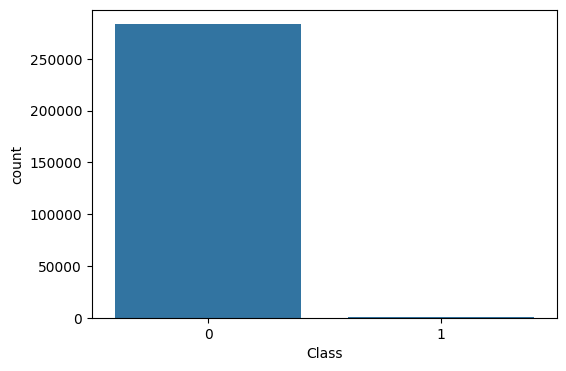

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class')

In [11]:
df[df.Class == 0].Amount.describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

In [12]:
df[df.Class == 1].Amount.describe()

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

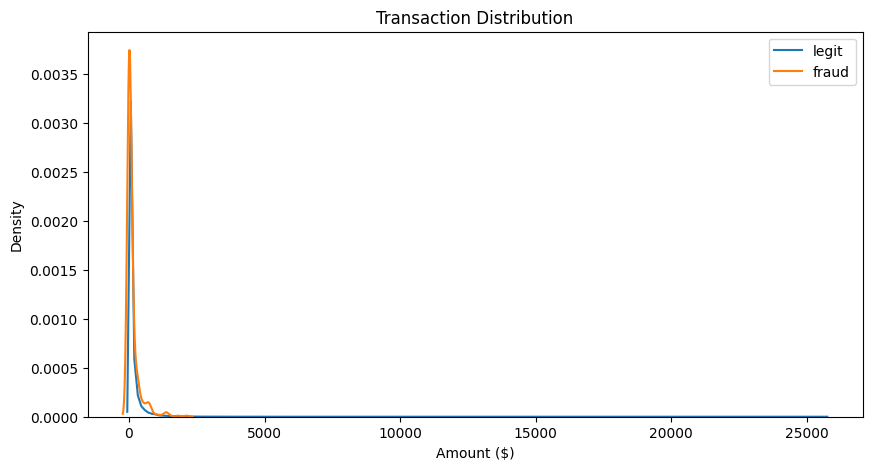

In [13]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df.Class == 0].Amount, label='legit')
sns.kdeplot(df[df.Class == 1].Amount, label='fraud')
plt.title('Transaction Distribution')
plt.xlabel('Amount ($)')
plt.legend()
plt.show()

In [14]:
df[df.Class == 0].Time.describe()

count    283253.000000
mean      94835.058093
std       47475.550607
min           0.000000
25%       54233.000000
50%       84711.000000
75%      139308.000000
max      172792.000000
Name: Time, dtype: float64

In [15]:
df[df.Class == 1].Time.describe()

count       473.000000
mean      80450.513742
std       48636.179973
min         406.000000
25%       41203.000000
50%       73408.000000
75%      129095.000000
max      170348.000000
Name: Time, dtype: float64

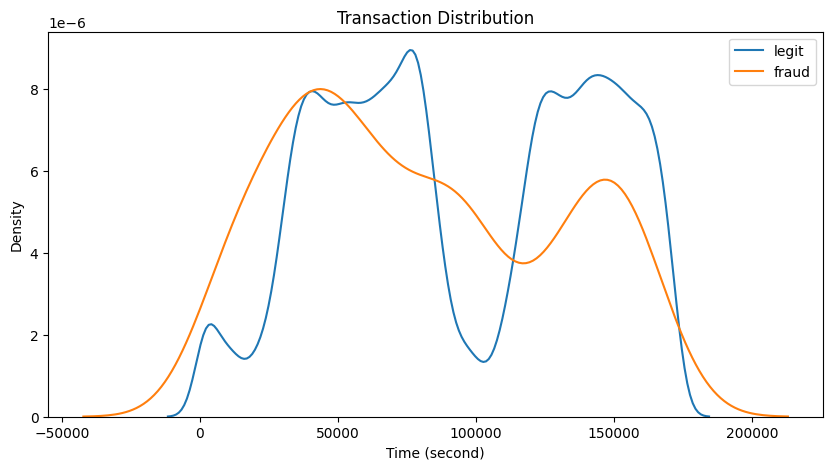

In [16]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df.Class == 0].Time, label='legit')
sns.kdeplot(df[df.Class == 1].Time, label='fraud')
plt.title('Transaction Distribution')
plt.xlabel('Time (second)')
plt.legend()
plt.show()

<Axes: >

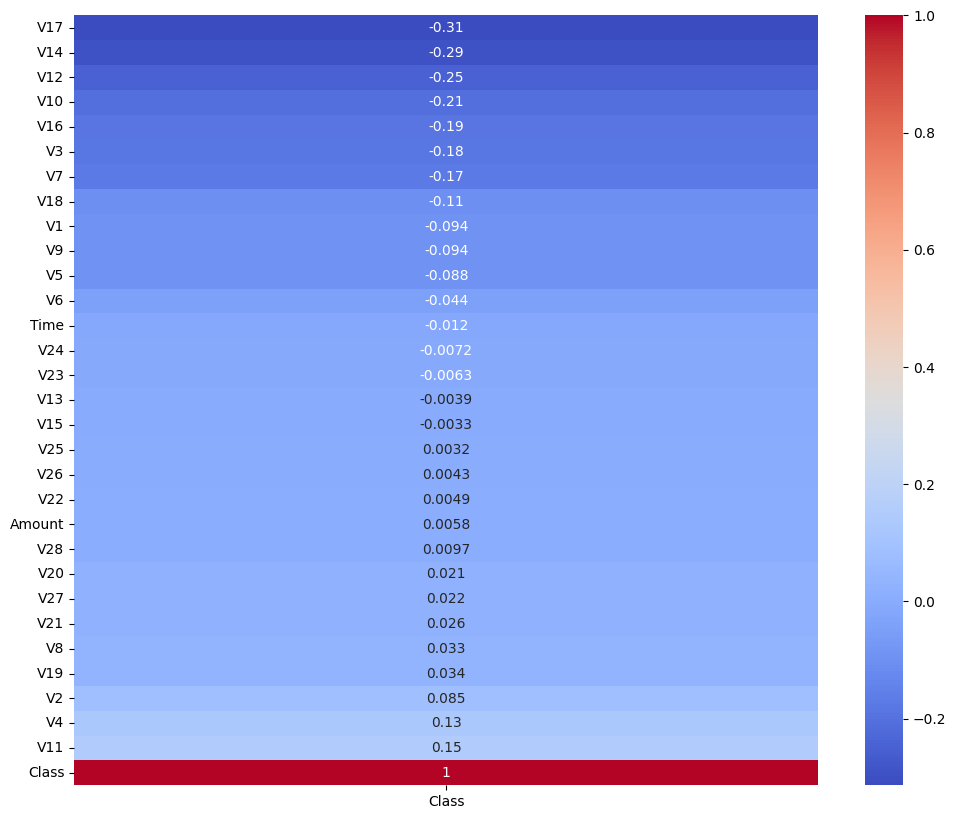

In [17]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr[['Class']].sort_values(by='Class'), annot=True, cmap='coolwarm')

In [9]:
# RobustScaler is much better for imbalanced dataset
from sklearn.preprocessing import RobustScaler

In [10]:
scaler = RobustScaler()

df.loc[:, 'scaled_amount'] = scaler.fit_transform(df[['Amount']])
df.loc[:, 'scaled_time'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Time', 'Amount'], axis=1)

In [20]:
df.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.774718,-0.995290
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.268530,-0.995290
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.959811,-0.995279
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.411487,-0.995279
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.667362,-0.995267


## Training model

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [24]:
X = df.drop('Class', axis=1)
y = df.Class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

In [29]:
# Hyperparameters Grid
model_configs = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10],
            'class_weight': ['balanced', None]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        'params': {
            'max_depth': [3, 6],
            'learning_rate': [0.01, 0.1],
            'scale_pos_weight': [1, 580]
        }
    }
}

In [27]:
# Create a Stratified 3-Fold Cross Validation strategy for the grid search
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results_summary = []

for name, config in model_configs.items():
    print(f"\n==================== Tuning {name} ====================")
    
    # Set up GridSearchCV targeting Average Precision (PR-AUC)
    clf = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=cv_strategy,
        scoring='average_precision', 
        verbose=1,
        n_jobs=-1
    )
    
    # Fit model on training data
    clf.fit(X_train, y_train)
    best_model = clf.best_estimator_
    
    print(f"Best Parameters for {name}: {clf.best_params_}")
    
    # Predict on unseen testing data
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate performance metrics
    pr_auc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Print out detailed text report
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
    
    # Store performance for final comparison table
    results_summary.append({
        'Model': name,
        'Best Params': clf.best_params_,
        'PR-AUC (Precision-Recall)': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4)
    })


==================== Tuning LogisticRegression ====================
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters for LogisticRegression: {'C': 1, 'penalty': 'l2'}
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746


==================== Tuning DecisionTree ====================
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Parameters for DecisionTree: {'max_depth': 5, 'min_samples_split': 5}
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.88      0.69      0.78        95

    accuracy                           1.00     56746
   macro avg       0.94      0.85      0.89     56746
weighted

C:\Users\GIA DAT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:26:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'scale_pos_weight': 1}
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [28]:
summary_df = pd.DataFrame(results_summary)
# Sort by PR-AUC because it's the gold-standard metric for highly imbalanced anomaly detection
summary_df = summary_df.sort_values(by='PR-AUC (Precision-Recall)', ascending=False)

print("\n==================== FINAL PERFORMANCE COMPARISON ====================")
print(summary_df.to_string(index=False))


==================== FINAL PERFORMANCE COMPARISON ====================
             Model                                                   Best Params  PR-AUC (Precision-Recall)  ROC-AUC
           XGBoost {'learning_rate': 0.1, 'max_depth': 6, 'scale_pos_weight': 1}                     0.7934   0.9746
      RandomForest  {'class_weight': None, 'max_depth': 10, 'n_estimators': 100}                     0.7881   0.9644
LogisticRegression                                     {'C': 1, 'penalty': 'l2'}                     0.6964   0.9565
      DecisionTree                      {'max_depth': 5, 'min_samples_split': 5}                     0.6393   0.9060
